## Домашнее задание
Чем лучше бустить? Тестируем алгоритмы бустинга в бою.

### Цель:
В этом домашнем задании вам предстоит провести детективную работу и узнать, какой же алгоритм бустинга работает лучше всего (конечно, применительно к конкретной задаче).

#### Описание/Пошаговая инструкция выполнения домашнего задания:
##### Часть 1. EDA

- Выберите любой интересующий вас датасет по классификации или регрессии (можно взять из репозитория https://archive.ics.uci.edu/ml/datasets.php, еще неплохие и востребованные на практике варианты - предсказание оттока пользователей https://www.kaggle.com/blastchar/telco-customer-churn или предсказание Customer Livetime Value (CLV или LTV) - https://www.kaggle.com/pankajjsh06/ibm-watson-marketing-customer-value-data
- По выбранному датасету проведите EDA, познакомьтесь с признаками, посмотрите зависимости и т.д.

##### Часть 2. Preprocessing & Feature Engineering

- Хотя цель этого задания - посмотреть на работу алгоритмов, тем не менее пропускать препроцессинг нельзя :)
- Так что переведите категориальные переменные в уникальные лейблы при помощи LabelEncoder, попробуйте добавить новые переменные и выкинуть лишние и, наконец, разбейте данные на train-test.

##### Часть 3. Who's the mightiest of them all?

- Постройте 4 варианта градиентного бустинга, используя значения гиперпараметров “из коробки”: реализация из sklearn, XGBoost, CatBoost, LightGBM
- Проверьте качество на отложенной выборке, кто пока лидирует?
- Теперь проведите настройку гиперпараметров моделей на кросс-валидации, можно настраивать только самые основные гиперпараметры - число итераций бустинга, max_features, subsample и т.д.
- Снова проверьте качество уже настроенных моделей. Кто в итоге победил?

### Критерии оценки:
- EDA для выбранного датасета - 1 балл.
- Preprocessing - 1 балл.
- Построение моделей из коробки и проверка качества - 4 балла.
- Настройка гиперпараметров моделей и проверка качества - 4 балла.

## Решение

В качестве материала для ДЗ выбран [датасет по предсказанию Customer Livetime Value (CLV или LTV)](https://www.kaggle.com/datasets/pankajjsh06/ibm-watson-marketing-customer-value-data), он предварительно сохранён в локальный файл [WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv](./WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv).

Мне не удалось найти описание назначения признаков, а описание самого датасета слабо затрагивает предметную область.\
Поэтому при работе с признаками исхожу из того, что IBM Watson - это [суперкомпьютер](https://ru.wikipedia.org/wiki/IBM_Watson) и целевой переменной [Customer Lifetime Value](https://ru.wikipedia.org/wiki/%D0%9F%D0%BE%D0%B6%D0%B8%D0%B7%D0%BD%D0%B5%D0%BD%D0%BD%D0%B0%D1%8F_%D1%86%D0%B5%D0%BD%D0%BD%D0%BE%D1%81%D1%82%D1%8C_%D0%BA%D0%BB%D0%B8%D0%B5%D0%BD%D1%82%D0%B0) датасет описывает доход с одного клиента за весь период пользования некой услугой доступа к вычислительным сервисам данного компьютера.

In [1]:
import pandas as pd
import numpy as np

### 1. EDA

In [2]:
df = pd.read_csv('./WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv', sep=',')

In [3]:
# Не удалось вывести на печать весь набор признаков вызовами df.head() или print(df[:5])
# Поэтому вывожу двумя командами
PRINT_COLUMN_CHUNK_SIZE = 13

In [4]:
df.iloc[:5, :PRINT_COLUMN_CHUNK_SIZE]

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,Location Code,Marital Status,Monthly Premium Auto
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,Suburban,Married,69
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,Suburban,Single,94
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,Suburban,Married,108
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,Suburban,Married,106
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,Rural,Single,73


In [5]:
df.iloc[:5, PRINT_COLUMN_CHUNK_SIZE:]

,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,32,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,13,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,18,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,18,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,12,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


In [79]:
# Определение категорий признаков
target = ['Customer Lifetime Value']

drop_features = [
    'Customer', 
    'State', 
    'Response', 
    'Effective To Date', 
    'Location Code', 
    'Marital Status', 
    'Monthly Premium Auto', 
    'Number of Open Complaints', 
    'Number of Policies',
    'Policy Type', 
    'Sales Channel',
    'Vehicle Class',
    'Vehicle Size'
    ]

numeric_features = [
    'Months Since Last Claim',
    'Months Since Policy Inception',
    'Total Claim Amount'
]

category_features = [
    'EmploymentStatus'
]

ordered_features = [
    'Coverage',
    'Education',
    'Renew Offer Type',
    'Policy'
]

binary_features = [
    'Gender'
]

In [80]:
clean_df = df.drop(labels=drop_features, axis=1)

# Пропусков нет
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer Lifetime Value        9134 non-null   float64
 1   Coverage                       9134 non-null   object 
 2   Education                      9134 non-null   object 
 3   EmploymentStatus               9134 non-null   object 
 4   Gender                         9134 non-null   object 
 5   Income                         9134 non-null   int64  
 6   Months Since Last Claim        9134 non-null   int64  
 7   Months Since Policy Inception  9134 non-null   int64  
 8   Policy                         9134 non-null   object 
 9   Renew Offer Type               9134 non-null   object 
 10  Total Claim Amount             9134 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 785.1+ KB


In [81]:
for feature in ordered_features + category_features + binary_features:
    print(f'{feature}: {clean_df[feature].unique()}')

Coverage: ['Basic' 'Extended' 'Premium']
Education: ['Bachelor' 'College' 'Master' 'High School or Below' 'Doctor']
Renew Offer Type: ['Offer1' 'Offer3' 'Offer2' 'Offer4']
Policy: ['Corporate L3' 'Personal L3' 'Corporate L2' 'Personal L1' 'Special L2'
 'Corporate L1' 'Personal L2' 'Special L1' 'Special L3']
EmploymentStatus: ['Employed' 'Unemployed' 'Medical Leave' 'Disabled' 'Retired']
Gender: ['F' 'M']


In [ ]:
# Преобразование нечисловых признаков
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import make_column_transformer

def get_encoded_feature_name(feature, category):
    return str(feature) + "_" + str(category)


ordinal_encoder = OrdinalEncoder(categories=[
        ['Basic', 'Extended', 'Premium'],
        ['High School or Below', 'College', 'Bachelor',  'Master', 'Doctor'],
        ['Offer1', 'Offer2', 'Offer3', 'Offer4'],
        ['Personal L1', 'Personal L2', 'Personal L3',  'Corporate L1', 'Corporate L2',  'Corporate L3', 'Special L1',   'Special L2',  'Special L3']
    ],
    dtype=np.int16
)

binary_encoder = OneHotEncoder(
    sparse_output=False, 
    drop='if_binary', 
    feature_name_combiner=get_encoded_feature_name,
    dtype=np.byte
)

category_encoder = OneHotEncoder(
    sparse_output=False, 
    feature_name_combiner=get_encoded_feature_name,
    dtype=np.byte
)


column_transformer = make_column_transformer(
    (ordinal_encoder, ordered_features + category_features),
    (binary_encoder, binary_features)
)

encoded_df = clean_df.copy()
encoded_df[binary_encoder.get_feature_names_out()] = binary_encoder.fit_transform(encoded_df[binary_features])
encoded_df[ordered_features] = ordinal_encoder.fit_transform(encoded_df[ordered_features])
encoded_df[category_encoder.get_feature_names_out()] = category_encoder.fit_transform(encoded_df[category_features])

encoded_df = encoded_df.drop(binary_features + category_features, axis=1)
encoded_df.head()

,Customer Lifetime Value,Coverage,Education,Income,Months Since Last Claim,Months Since Policy Inception,Policy,Renew Offer Type,Total Claim Amount,Gender_M,EmploymentStatus_Disabled,EmploymentStatus_Employed,EmploymentStatus_Medical Leave,EmploymentStatus_Retired,EmploymentStatus_Unemployed
0,2763.519279,0,2,56274,32,5,5,0,384.811147,0,0,1,0,0,0
1,6979.535903,1,2,0,13,42,2,2,1131.464935,0,0,0,0,0,1
2,12887.431650,2,2,48767,18,38,2,0,566.472247,0,0,1,0,0,0
3,7645.861827,0,2,0,18,65,4,0,529.881344,1,0,0,0,0,1
4,2813.692575,0,2,43836,12,44,0,0,138.130879,1,0,1,0,0,0


array([[<Axes: title={'center': 'Customer Lifetime Value'}>,
        <Axes: title={'center': 'Coverage'}>,
        <Axes: title={'center': 'Education'}>],
       [<Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Months Since Last Claim'}>,
        <Axes: title={'center': 'Months Since Policy Inception'}>],
       [<Axes: title={'center': 'Policy'}>,
        <Axes: title={'center': 'Renew Offer Type'}>,
        <Axes: title={'center': 'Total Claim Amount'}>],
       [<Axes: title={'center': 'Gender_M'}>, <Axes: >, <Axes: >]],
      dtype=object)

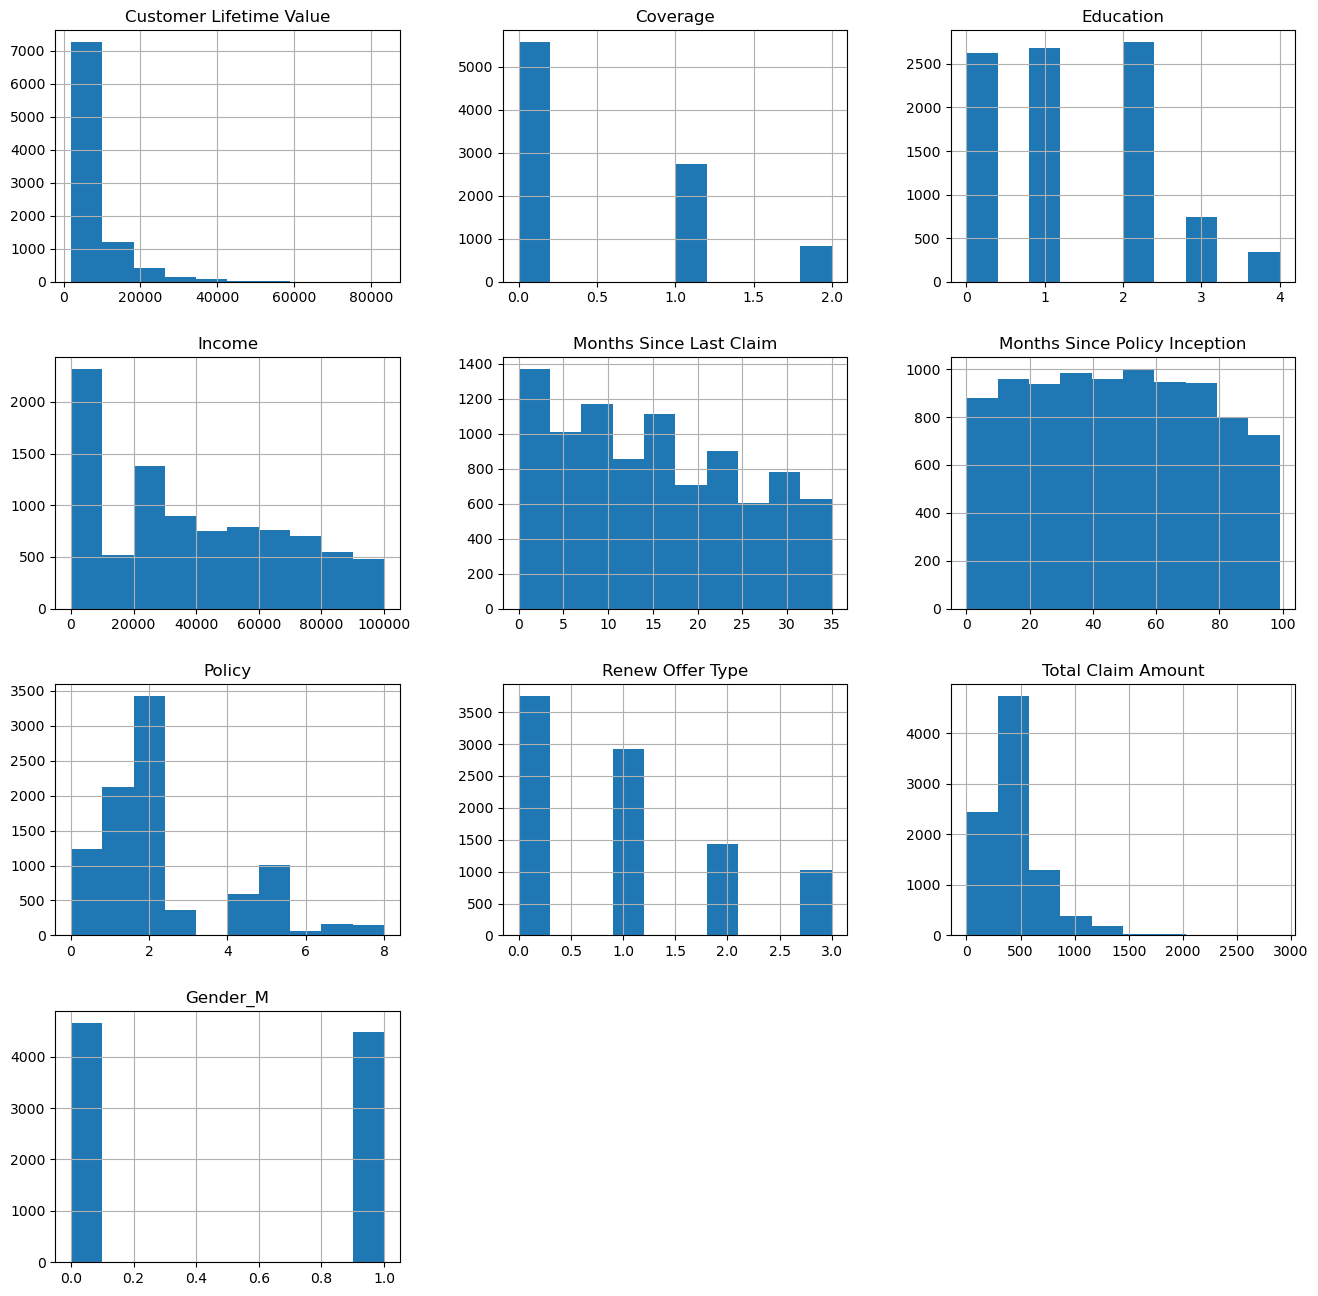

In [ ]:
# Гистограмы распределения всех числовых значений за исключением категориальных признаков
syntetic_category_feature = [column  for column in encoded_df.columns for category_feature in category_features if category_feature in column]

encoded_df.drop(syntetic_category_feature, axis=1).hist(figsize=(16,16))

In [107]:
encoded_df.describe(include='all')

,Customer Lifetime Value,Coverage,Education,Income,Months Since Last Claim,Months Since Policy Inception,Policy,Renew Offer Type,Total Claim Amount,Gender_M,EmploymentStatus_Disabled,EmploymentStatus_Employed,EmploymentStatus_Medical Leave,EmploymentStatus_Retired,EmploymentStatus_Unemployed
count,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.00000,9134.000000,9134.000000,9134.000000,9134.000000
mean,8004.940475,0.480622,1.288373,37657.380009,15.097000,48.064594,2.214692,0.970221,434.088794,0.490037,0.04434,0.623823,0.047296,0.030874,0.253668
std,6870.967608,0.655817,1.079984,30379.904734,10.073257,27.905991,1.782244,1.007576,290.500092,0.499928,0.20586,0.484452,0.212282,0.172985,0.435133
min,1898.007675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.099007,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3994.251794,0.000000,0.000000,0.000000,6.000000,24.000000,1.000000,0.000000,272.258244,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,5780.182197,0.000000,1.000000,33889.500000,14.000000,48.000000,2.000000,1.000000,383.945434,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000
75%,8962.167041,1.000000,2.000000,62320.000000,23.000000,71.000000,3.000000,2.000000,547.514839,1.000000,0.00000,1.000000,0.000000,0.000000,1.000000
max,83325.381190,2.000000,4.000000,99981.000000,35.000000,99.000000,8.000000,3.000000,2893.239678,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
